In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
# %matplotlib notebook

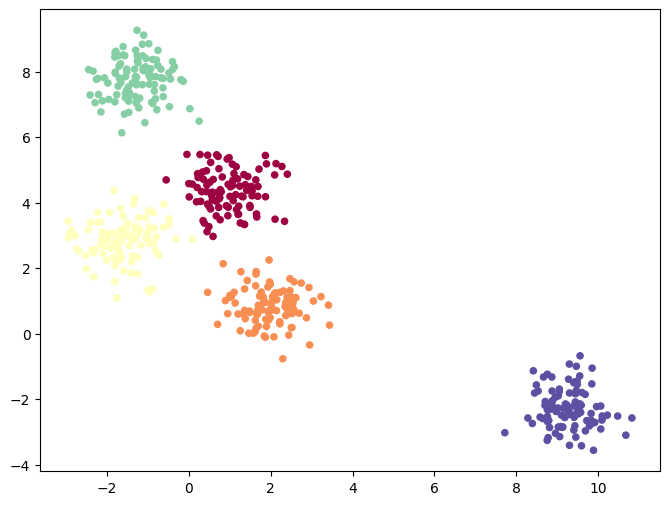

In [48]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5,
                           cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(y)))])
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)

Agglomerative clustering using complete linkage

In [49]:
def calc_all_distances(points):
    all_distances = {}
    for i in range(len(points)):
        for j in range(i + 1):
            key_distance = '{}_{}'.format(i, j)
            reverse_key_distance = '{}_{}'.format(j, i)
            all_distances[key_distance] = all_distances[reverse_key_distance] = np.linalg.norm(points[i]-points[j])
    return all_distances

all_distances = calc_all_distances(X)

In [50]:
def calc_max_distance_of_two_clusters(cluster_a, cluster_b, all_distances):

    return max([all_distances['{}_{}'.format(keyword_index_a,keyword_index_b)] for keyword_index_a in cluster_a for keyword_index_b in cluster_b])

def compute_next_merge(clusters, all_distances):
    labels= list(clusters.keys())
    min_distance = calc_max_distance_of_two_clusters(clusters[labels[0]],clusters[labels[1]],all_distances )
    clusters_to_merge = [labels[0], labels[1]]
    for i in range (len(labels)-1):
        for j in range(i+1,len(labels)):
            curr_min_distance= calc_max_distance_of_two_clusters(clusters[labels[i]],clusters[labels[j]], all_distances)
            if curr_min_distance < min_distance:
                min_distance = curr_min_distance
                clusters_to_merge = [labels[i],labels[j]]
    return min_distance, clusters_to_merge

def merge_clusters(current_clusters,clusters_to_merge):

    current_clusters[clusters_to_merge[0]] += current_clusters[clusters_to_merge[1]]
    del current_clusters[clusters_to_merge[1]]
    return current_clusters

def run_agglomerative_clustering(points, n_clusters=1):
    resulted_clusters={i: [i] for i in range(len(points))}
    while len(resulted_clusters)>n_clusters:
        min_distance, clusters_to_merge=  compute_next_merge(resulted_clusters, all_distances)

        if (len(resulted_clusters)) % 10 == 0:
            print ('len(clusters)= {:,} distance = {}'.format(len(resulted_clusters), min_distance))

        resulted_clusters= merge_clusters(resulted_clusters, clusters_to_merge)
    return resulted_clusters

In [51]:
n_clusters= 5
results = run_agglomerative_clustering(X, n_clusters=n_clusters)
print ('\nClustering complete.')

len(clusters)= 500 distance = 0.006352393069545862
len(clusters)= 490 distance = 0.022962819364211833
len(clusters)= 480 distance = 0.03885267528188279
len(clusters)= 470 distance = 0.043351851005828765
len(clusters)= 460 distance = 0.04804558167832638
len(clusters)= 450 distance = 0.057772181953295594
len(clusters)= 440 distance = 0.06307942637142751
len(clusters)= 430 distance = 0.07206125352911633
len(clusters)= 420 distance = 0.07775867626367369
len(clusters)= 410 distance = 0.08503217733680343
len(clusters)= 400 distance = 0.09117351326637446
len(clusters)= 390 distance = 0.09683281597476992
len(clusters)= 380 distance = 0.1024705012453015
len(clusters)= 370 distance = 0.10840529828590828
len(clusters)= 360 distance = 0.11342046410933697
len(clusters)= 350 distance = 0.11825105848905647
len(clusters)= 340 distance = 0.1263739396101331
len(clusters)= 330 distance = 0.1364416219945109
len(clusters)= 320 distance = 0.1452490866786814
len(clusters)= 310 distance = 0.159633526274852
le

Text(0.5, 1.0, 'Agglomerative Clustering using complete')

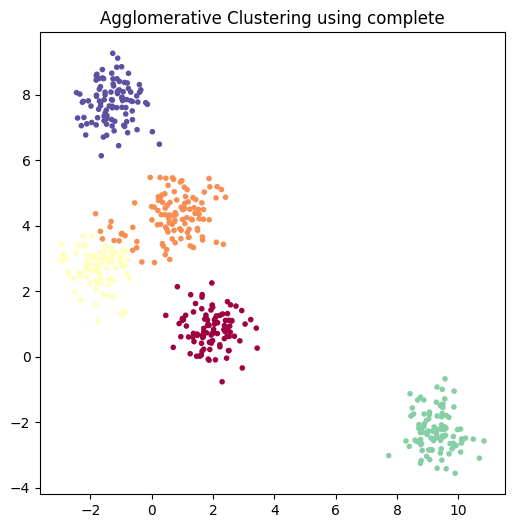

In [52]:
labels = np.zeros(len(X), dtype=int)

for i, cluster in enumerate(results.values()):
    labels[cluster] = i

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[labels], marker= '.')
plt.title ('Agglomerative Clustering using complete')

In [53]:
# using sklearn
from sklearn.cluster import AgglomerativeClustering

clf = AgglomerativeClustering(n_clusters = 5, linkage = 'complete')
predicted = clf.fit_predict(X, y)

Text(0.5, 1.0, 'AgglomerativeClustering using complete with sklearn')

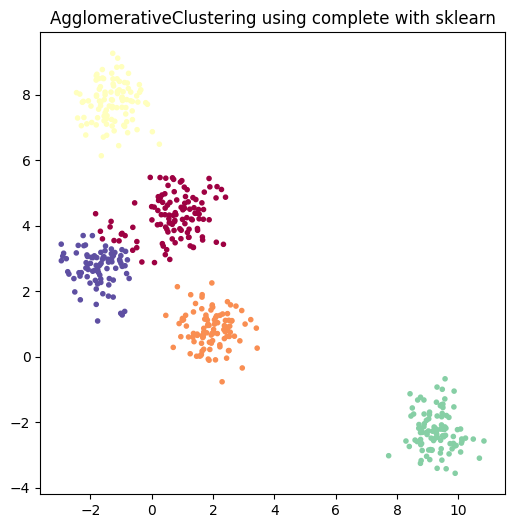

In [54]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[predicted], marker= '.')
plt.title ('AgglomerativeClustering using complete with sklearn')

Agglomerative clustering using single linkage

In [55]:
def calc_all_distances(points):
    all_distances = {}
    for i in range(len(points)):
        for j in range(i + 1):
            key_distance = '{}_{}'.format(i, j)
            reverse_key_distance = '{}_{}'.format(j, i)
            all_distances[key_distance] = all_distances[reverse_key_distance] = np.linalg.norm(points[i]-points[j])
    return all_distances

all_distances = calc_all_distances(X)

In [56]:
def calc_min_distance_of_two_clusters(cluster_a, cluster_b, all_distances):

    return min([all_distances['{}_{}'.format(keyword_index_a,keyword_index_b)] for keyword_index_a in cluster_a for keyword_index_b in cluster_b])

def compute_next_merge(clusters, all_distances):
    labels= list(clusters.keys())
    min_distance = calc_min_distance_of_two_clusters(clusters[labels[0]],clusters[labels[1]],all_distances )
    clusters_to_merge = [labels[0], labels[1]]
    for i in range (len(labels)-1):
        for j in range(i+1,len(labels)):
            curr_min_distance= calc_min_distance_of_two_clusters(clusters[labels[i]],clusters[labels[j]], all_distances)
            if curr_min_distance < min_distance:
                min_distance = curr_min_distance
                clusters_to_merge = [labels[i],labels[j]]
    return min_distance, clusters_to_merge

def merge_clusters(current_clusters,clusters_to_merge):

    current_clusters[clusters_to_merge[0]] += current_clusters[clusters_to_merge[1]]
    del current_clusters[clusters_to_merge[1]]
    return current_clusters

def run_agglomerative_clustering(points, n_clusters=1):
    resulted_clusters={i: [i] for i in range(len(points))}
    while len(resulted_clusters)>n_clusters:
        min_distance, clusters_to_merge=  compute_next_merge(resulted_clusters, all_distances)

        if (len(resulted_clusters)) % 10 == 0:
            print ('len(clusters)= {:,} distance = {}'.format(len(resulted_clusters), min_distance))

        resulted_clusters= merge_clusters(resulted_clusters, clusters_to_merge)
    return resulted_clusters

In [57]:
n_clusters= 5
results = run_agglomerative_clustering(X, n_clusters=n_clusters)
print ('\nClustering complete.')

len(clusters)= 500 distance = 0.006352393069545862
len(clusters)= 490 distance = 0.022962819364211833
len(clusters)= 480 distance = 0.03723317051445359
len(clusters)= 470 distance = 0.04073414603378936
len(clusters)= 460 distance = 0.04466336223562292
len(clusters)= 450 distance = 0.05158223742120575
len(clusters)= 440 distance = 0.05836328021328444
len(clusters)= 430 distance = 0.06307942637142751
len(clusters)= 420 distance = 0.06979926290648931
len(clusters)= 410 distance = 0.07609885544758688
len(clusters)= 400 distance = 0.07958344006635855
len(clusters)= 390 distance = 0.0845375327314368
len(clusters)= 380 distance = 0.08829224898640811
len(clusters)= 370 distance = 0.09138501510669728
len(clusters)= 360 distance = 0.09707178633171046
len(clusters)= 350 distance = 0.10150157844091252
len(clusters)= 340 distance = 0.1038948254934588
len(clusters)= 330 distance = 0.10840529828590828
len(clusters)= 320 distance = 0.11217642549565941
len(clusters)= 310 distance = 0.11658254669979648


Text(0.5, 1.0, 'Agglomerative Clustering using single')

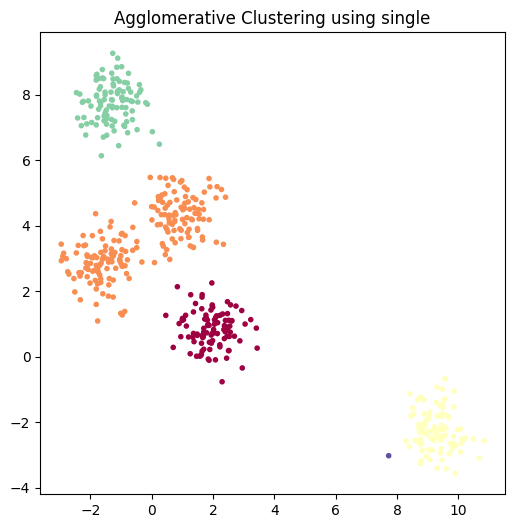

In [58]:
labels = np.zeros(len(X), dtype=int)

for i, cluster in enumerate(results.values()):
    labels[cluster] = i

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[labels], marker= '.')
plt.title ('Agglomerative Clustering using single')

In [59]:
# using sklearn
from sklearn.cluster import AgglomerativeClustering

clf = AgglomerativeClustering(n_clusters = 5, linkage = 'single')
predicted = clf.fit_predict(X, y)

Text(0.5, 1.0, 'Agglomerative Clustering using single with sklearn')

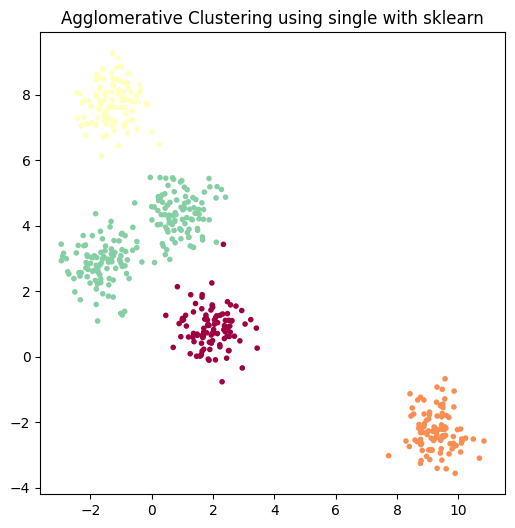

In [67]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[predicted], marker= '.')
plt.title ('Agglomerative Clustering using single with sklearn')

DBSCAN

In [61]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(min_samples=2, ).fit(X, y)
dbscan_pred = dbscan.fit_predict(X, y)

Text(0.5, 1.0, 'Clustering with DBSCAN')

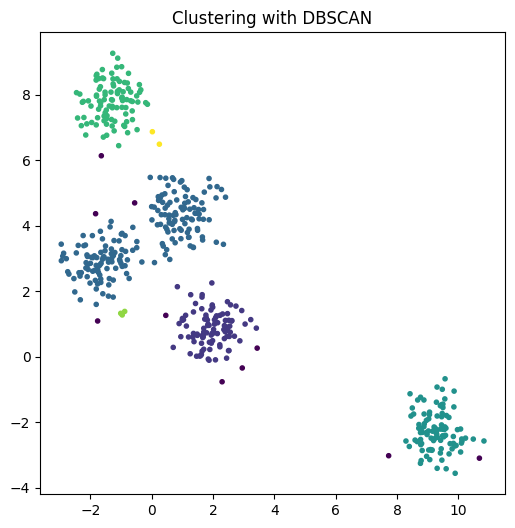

In [62]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= dbscan_pred, marker= '.')
plt.title ('Clustering with DBSCAN')

Use albow method to determine the best k for Kmeans

In [63]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

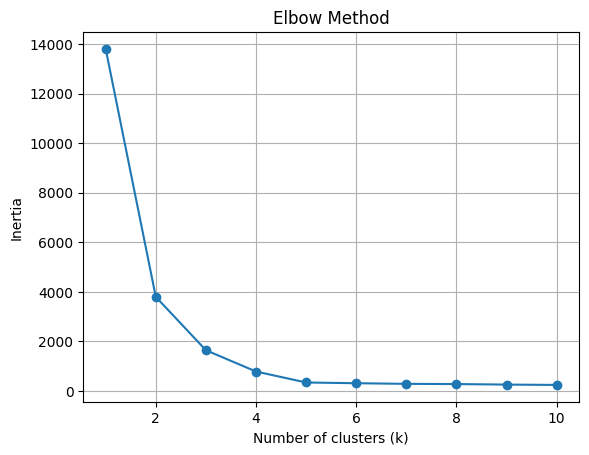

In [64]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid()

In [65]:
clf = KMeans(n_clusters=4, random_state=42)
predicted = clf.fit_predict(X)

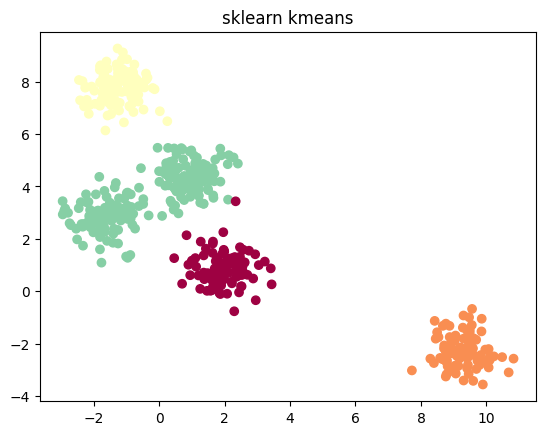

In [66]:
plt.figure()
plt.scatter(X[:,0], X[:,1], c= colors[predicted])
plt.title ('sklearn kmeans')
plt.show()